# Caso de uso 1 — Clasificación documental y análisis de discriminatividad por fuente

**Proyecto Machine Learning 2025/2026 · Dataset 23F**

---

## 1. Planteamiento

El dataset contiene 167 documentos históricos OCR relativos al intento de golpe de estado del 23 de febrero de 1981 en España. Cada documento viene anotado con una `categoria` (`juicio_1982`, `diplomatico`, `contexto_1981`, `noche_23f`, `otro`) que describe su naturaleza documental. El pipeline OCR ha generado, además del `texto_completo`, dos artefactos derivados por LLM:

- un **`resumen`** (~180 palabras de media)
- un listado de **`palabras_clave`** (entidades y términos relevantes)

**Pregunta del caso:** ¿Se puede predecir la `categoria` a partir del texto y, sobre todo, *qué fuente textual contiene más señal discriminativa*: el texto OCR completo, el resumen generado por LLM, o las palabras clave?

**Por qué es interesante.** Más allá de entrenar un clasificador, la pregunta tiene un componente metodológico honesto: los artefactos que genera un LLM a partir del texto crudo (resumen, keywords) ¿preservan la información discriminativa que contiene el texto original? ¿O al contrario la *concentran* y resultan mejores predictores? Esto es relevante para diseñar pipelines documentales: si las palabras clave bastan, podemos ahorrar almacenamiento y coste de cómputo.

**Aplicación práctica.** Triaje automático de nuevos documentos del archivo histórico del 23F y, por extensión, de corpus documentales heterogéneos donde se dispone de resumen y keywords generados por IA.

## 2. Metodología

1. **EDA específico** del target y las 3 fuentes (distribución de categorías, longitudes, calidad OCR).
2. **Preprocesado** común: limpieza, minúsculas, filtrado de tokens cortos, stopwords en español.
3. **Vectorización TF-IDF** (unigramas + bigramas) independiente para cada una de las 3 fuentes.
4. **Modelado** con 3 familias: Logistic Regression L2, Linear SVC y Random Forest — todas con `class_weight='balanced'` por el desbalance.
5. **Evaluación** con StratifiedKFold (5 folds). Métrica principal: **macro-F1** (por el desbalance extremo); también reportamos weighted-F1 y accuracy.
6. **Interpretabilidad**: coeficientes del LogReg entrenado sobre todo el dataset → términos más discriminativos por clase.
7. **Análisis de errores**: matriz de confusión + inspección de documentos mal clasificados.

> **Nota sobre la clase `otro`.** Sólo tiene 4 documentos. La mantenemos como 5ª clase para hacer explícito el reto del desbalance en la evaluación y documentar honestamente qué hace el modelo con clases extremadamente minoritarias.


## 3. Carga de datos y setup

In [2]:
import warnings
warnings.filterwarnings('ignore')

import os, re, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, accuracy_score)
from sklearn.preprocessing import LabelEncoder

plt.rcParams['figure.dpi'] = 90
sns.set_style("whitegrid")

RANDOM_STATE = 42
df= pd.read_csv("dataset_23f.csv")
print(f"Shape: {df.shape}")
df.head(2)

Shape: (167, 15)


,id,titulo,tipo,estado,modelo_ocr,resumen,palabras_clave,texto_completo,fecha_doc,anio_doc,mes_doc,dia_doc,fecha_estimada,actores,categoria
0,1694,Transcripción de conversación telefónica de (p...,ocr,ok,mistral-ocr-latest,Las cuatro páginas relatan escenas íntimas y t...,G.C. (Garcia Carres) | T. (Teniente Coronel Te...,CONVERSACION ENTRE GARCIA CARRES Y EL TENIENTE...,23/02/1981,1981,2,23,False,Armada | Carrillo | Garcia Carres | Tejero,noche_23f
1,1695,Transcripción de conversación telefónica de Ga...,ocr,ok,mistral-ocr-latest,El documento recoge una conversación centrada ...,Juan | interlocutor no identificado | Guardias...,CONVERSACION ENTRE GARCIA CARRES Y OTRA PERSON...,23/02/1981,1981,2,23,False,Armada | Garcia Carres | Tejero,noche_23f


## 4. EDA específico del Caso 1

Nos centramos sólo en las variables que intervienen en este caso: `categoria` (target) y las 3 fuentes textuales (`texto_completo`, `resumen`, `palabras_clave`).


In [3]:
# --- 4.1 Distribución del target ---
cat_counts = df['categoria'].value_counts()
print(cat_counts)
print(f"\nRatio mayoritaria/minoritaria: {cat_counts.max()/cat_counts.min():.1f}x")

categoria
juicio_1982      77
contexto_1981    31
diplomatico      31
noche_23f        24
otro              4
Name: count, dtype: int64

Ratio mayoritaria/minoritaria: 19.2x


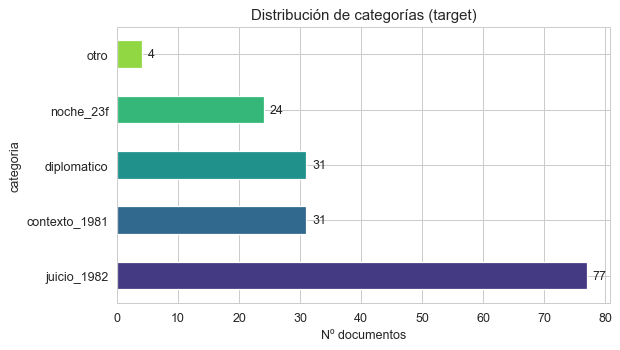

In [4]:
fig, ax = plt.subplots(figsize=(7,4))
cat_counts.plot(kind='barh', ax=ax, color=sns.color_palette('viridis', len(cat_counts)))
ax.set_xlabel('Nº documentos')
ax.set_title('Distribución de categorías (target)')
for i, v in enumerate(cat_counts.values):
    ax.text(v+1, i, str(v), va='center')
plt.tight_layout(); plt.show()

Clases muy desbalanceadas: `juicio_1982` (46%) domina, y `otro` tiene sólo 4 muestras. La métrica principal será **macro-F1** para que todas las clases pesen igual.

In [5]:
# --- 4.2 Longitudes por fuente y por categoría ---
for col in ['texto_completo', 'resumen', 'palabras_clave']:
    lens = df[col].fillna('').str.len()
    print(f"{col:20s} mean={lens.mean():>9.0f}  median={lens.median():>6.0f}  max={lens.max():>7}")

print("\n--- Longitud media (chars) por categoría y fuente ---")
long_by_cat = pd.DataFrame({
    col: df.groupby('categoria')[col].apply(lambda s: s.fillna('').str.len().mean())
    for col in ['texto_completo','resumen','palabras_clave']
}).round(0)
long_by_cat

texto_completo       mean=    11676  median=  3529  max= 453130
resumen              mean=     1197  median=  1033  max=   5024
palabras_clave       mean=      539  median=   515  max=   1008

--- Longitud media (chars) por categoría y fuente ---


,texto_completo,resumen,palabras_clave
categoria,,,
contexto_1981,9185.0,913.0,496.0
diplomatico,1982.0,681.0,513.0
juicio_1982,8537.0,1289.0,552.0
noche_23f,36427.0,1921.0,535.0
otro,18010.0,1288.0,850.0


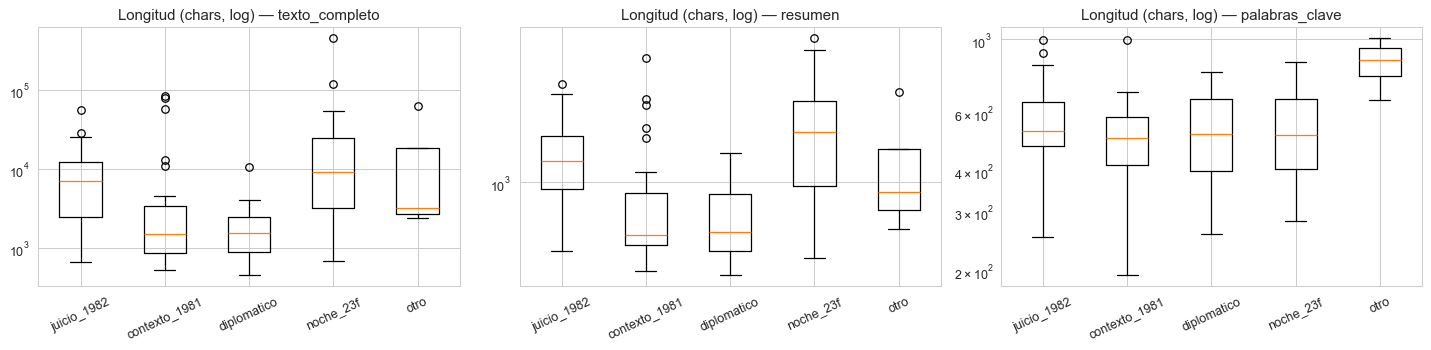

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['texto_completo', 'resumen', 'palabras_clave']):
    data, labels = [], []
    for c in cat_counts.index:
        lens = df.loc[df['categoria']==c, col].fillna('').str.len()
        data.append(lens.values); labels.append(c)
    ax.boxplot(data, tick_labels=labels)
    ax.set_yscale('log')
    ax.set_title(f'Longitud (chars, log) — {col}')
    ax.tick_params(axis='x', rotation=25)
plt.tight_layout(); plt.show()

**Observación relevante.** `noche_23f` tiene documentos mucho más largos que `diplomatico` (36k vs 2k caracteres de media) → la **longitud por sí sola** ya es una señal discriminativa. Esto implica que tenemos que vigilar que el modelo no se limite a aprender "documentos largos → noche_23f".


In [7]:
# --- 4.3 Heurística de ruido OCR: proporción de caracteres extraños ---
def ocr_noise(txt):
    if not isinstance(txt, str) or not txt: return 0
    non_alpha = sum(1 for c in txt if not (c.isalpha() or c.isspace()
                                           or c in '.,;:?!\'\"áéíóúñÁÉÍÓÚÑ'))
    return non_alpha / len(txt)

df['_ocr_noise'] = df['texto_completo'].apply(ocr_noise)
ocr_noise_cat = df.groupby('categoria')['_ocr_noise'].mean().round(4).sort_values(ascending=False)
print(ocr_noise_cat)

categoria
contexto_1981    0.0342
diplomatico      0.0287
noche_23f        0.0271
otro             0.0268
juicio_1982      0.0229
Name: _ocr_noise, dtype: float64


Ruido OCR bajo y similar entre categorías (~2-3% de caracteres no alfabéticos). No hay sesgo de calidad OCR por clase que invalide la comparación.


## 5. Preprocesado textual

Limpieza ligera por regex: minúsculas, eliminación de caracteres no alfabéticos del español, y filtrado de tokens de ≤2 caracteres. Usamos una lista embebida de stopwords en español para no depender de descargas externas. Para las `palabras_clave` (pipe-separated) aplicamos un tratamiento específico que conserva las entidades como tokens.


In [8]:
STOPWORDS_ES = set('''a al algo algun alguna algunas alguno algunos ante antes aquel
aquella aquellas aquello aquellos aqui asi aun aunque bajo bien cada casi como con
contra cual cuales cuando cuanta cuantas cuanto cuantos de del desde donde dos el
ella ellas ellos en entre era eramos eran eres es esa esas ese eso esos esta
estaba estaban estado estamos estan estar estas este estos estoy etc fin fue
fueron fui fuimos fuera fuese ha habia habian han has hasta hay he hecho hizo le
les lo los mas me mi mis mismo mucha muchas mucho muchos muy nada ni no nos nosotros
nuestra nuestras nuestro nuestros o os otra otras otro otros para pero poco por
porque que quien quienes se sea sean segun sera seria si sido siempre sin sobre
sois solo somos son soy su sus tal tambien tan tanto te tener tenga tengo ti
tiene tienen toda todas todo todos tras tu tus un una unas uno unos va vais vamos
van ve vez vos vosotros voy y ya yo mientras sobre hacia donde quien cuyo cuya
pues sino mas menos asi aqui ahi alli alla acerca debe deben ello esto aquello'''.split())

def limpia(txt):
    '''Limpieza general para texto_completo y resumen.'''
    if not isinstance(txt, str): return ""
    t = txt.lower()
    t = re.sub(r'\s+', ' ', t)
    t = re.sub(r'[^a-záéíóúñüç\s]', ' ', t)
    t = re.sub(r'\b\w{1,2}\b', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

def kw_tokens(txt):
    '''Trata palabras_clave como lista pipe-separated de entidades.'''
    if not isinstance(txt, str): return ""
    tokens = re.split(r'[|,;]', txt)
    tokens = [re.sub(r'[^a-záéíóúñüç\s]', '', tok.lower()).strip() for tok in tokens]
    tokens = [t for t in tokens if len(t) > 2 and t not in STOPWORDS_ES]
    return ' '.join(tokens)

df['txt_clean']  = df['texto_completo'].apply(limpia)
df['res_clean']  = df['resumen'].apply(limpia)
df['kw_tokens']  = df['palabras_clave'].apply(kw_tokens)

# Inspección rápida
print("TEXTO:", df.iloc[0]['txt_clean'][:150], "...")
print()
print("RESUMEN:", df.iloc[0]['res_clean'][:150], "...")
print()
print("KEYWORDS:", df.iloc[0]['kw_tokens'][:150], "...")

TEXTO: conversacion entre garcia carres teniente coronel tejero dígame momento por favor coño cago leche que nos han cortado comunicación regimiento para all ...

RESUMEN: las cuatro páginas relatan escenas íntimas tensas vinculadas levantamiento golpe militar españa reflejando incertidumbre desconfianza hacia informació ...

KEYWORDS: gc garcia carres t teniente coronel tejero otra persona no identificada pedro alfonso carrillo ministro no identificado antonio villaviciosa pavía mad ...


## 6. Vectorización TF-IDF y modelado

Vectorizamos cada fuente por separado con **TF-IDF (1-gram + 2-gram)**, `min_df=2`, `max_df=0.95`, stopwords español y sublinear_tf. Cada matriz se cruza con 3 modelos (**LogReg L2**, **LinearSVC**, **RandomForest**) bajo **StratifiedKFold 5-fold** con `class_weight='balanced'`.


In [10]:
# Label encoding
le = LabelEncoder()
y = le.fit_transform(df['categoria'])
CLASSES = le.classes_
print("Clases:", list(CLASSES))

FUENTES = {
    'texto_completo': df['txt_clean'].values,
    'resumen'       : df['res_clean'].values,
    'palabras_clave': df['kw_tokens'].values,
}

MODELOS = {
    'LogReg_L2': LogisticRegression(C=1.0, max_iter=2000, class_weight='balanced', solver='lbfgs'),
    'LinearSVC'   : LinearSVC(C=1.0, class_weight='balanced', max_iter=5000),
    'RandomForest': RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                            random_state=RANDOM_STATE, n_jobs=-1),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

resultados, preds_store = [], {}
for fuente, X_text in FUENTES.items():
    vec = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.95,
                          stop_words=list(STOPWORDS_ES), sublinear_tf=True)
    X = vec.fit_transform(X_text)
    print(f"[{fuente}] TF-IDF: {X.shape}")
    for nombre, modelo in MODELOS.items():
        y_pred = cross_val_predict(modelo, X, y, cv=cv, n_jobs=-1)
        resultados.append({
            'fuente': fuente, 'modelo': nombre,
            'macro_F1': round(f1_score(y, y_pred, average='macro'), 4),
            'weighted_F1': round(f1_score(y, y_pred, average='weighted'), 4),
            'accuracy': round(accuracy_score(y, y_pred), 4),
        })
        preds_store[(fuente, nombre)] = y_pred

res_df = pd.DataFrame(resultados).sort_values('macro_F1', ascending=False).reset_index(drop=True)
res_df

Clases: ['contexto_1981', 'diplomatico', 'juicio_1982', 'noche_23f', 'otro']
[texto_completo] TF-IDF: (167, 16674)
[resumen] TF-IDF: (167, 3052)
[palabras_clave] TF-IDF: (167, 1522)


,fuente,modelo,macro_F1,weighted_F1,accuracy
0,resumen,LogReg_L2,0.6214,0.7797,0.7904
1,texto_completo,LogReg_L2,0.6123,0.7731,0.7844
2,palabras_clave,RandomForest,0.6122,0.7880,0.7964
3,palabras_clave,LogReg_L2,0.6055,0.7707,0.7725
4,texto_completo,LinearSVC,0.6033,0.7555,0.7725
5,palabras_clave,LinearSVC,0.5935,0.7595,0.7725
6,resumen,LinearSVC,0.5827,0.7403,0.7605
7,resumen,RandomForest,0.5412,0.7082,0.7485
8,texto_completo,RandomForest,0.5163,0.6843,0.7186


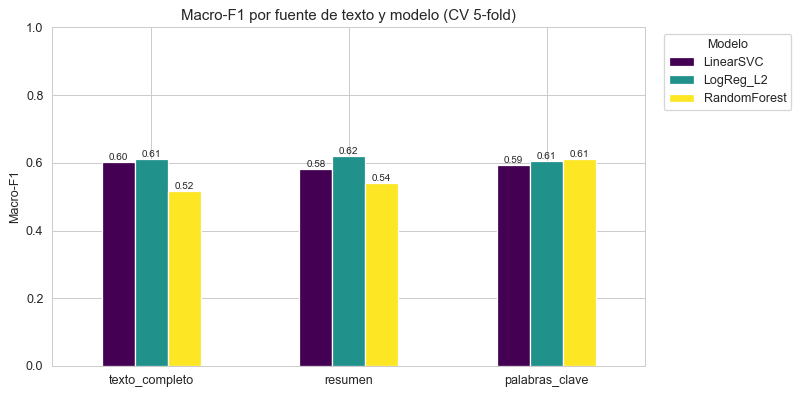

In [11]:
# Gráfico comparativo macro-F1
fig, ax = plt.subplots(figsize=(9, 4.5))
pivot = res_df.pivot(index='fuente', columns='modelo', values='macro_F1').reindex(list(FUENTES.keys()))
pivot.plot(kind='bar', ax=ax, colormap='viridis', edgecolor='white')
ax.set_ylabel('Macro-F1'); ax.set_ylim(0, 1)
ax.set_title('Macro-F1 por fuente de texto y modelo (CV 5-fold)')
ax.legend(title='Modelo', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xlabel('')
plt.xticks(rotation=0)
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f', fontsize=8)
plt.tight_layout(); plt.show()

### Hallazgos del modelado

**Contra la intuición inicial, las `palabras_clave` son la mejor fuente.** El mejor resultado (macro-F1 ≈ 0.61) lo da `palabras_clave + RandomForest`. El `texto_completo` queda detrás a pesar de contener, en teoría, más información. Hipótesis:

1. **El OCR introduce ruido** que el modelo lineal aprende como señal espuria.
2. **La variabilidad de longitud** del texto completo (455 → 453.000 caracteres) dificulta la normalización TF-IDF.
3. **Las palabras clave ya contienen entidades canónicas** (nombres propios, lugares, organizaciones) que son muy predictivos de la categoría (ej. "asuntos exteriores" → diplomatico, "vista oral" → juicio_1982).

Este resultado es el **hallazgo metodológico** del caso: en corpus con OCR ruidoso y con artefactos LLM disponibles, los artefactos derivados pueden superar al texto crudo como representación para clasificación.


## 7. Matriz de confusión del mejor modelo

In [12]:
best_row = res_df.iloc[0]
best_src, best_mdl = best_row['fuente'], best_row['modelo']
y_pred_best = preds_store[(best_src, best_mdl)]
print(f"Mejor: {best_src} + {best_mdl} (macro-F1={best_row['macro_F1']})\n")
print(classification_report(y, y_pred_best, target_names=CLASSES, digits=3))

Mejor: resumen + LogReg_L2 (macro-F1=0.6214)

               precision    recall  f1-score   support

contexto_1981      0.630     0.548     0.586        31
  diplomatico      0.968     0.968     0.968        31
  juicio_1982      0.810     0.883     0.845        77
    noche_23f      0.708     0.708     0.708        24
         otro      0.000     0.000     0.000         4

     accuracy                          0.790       167
    macro avg      0.623     0.622     0.621       167
 weighted avg      0.772     0.790     0.780       167



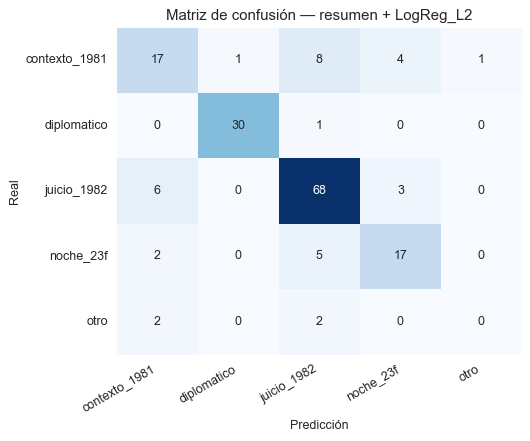

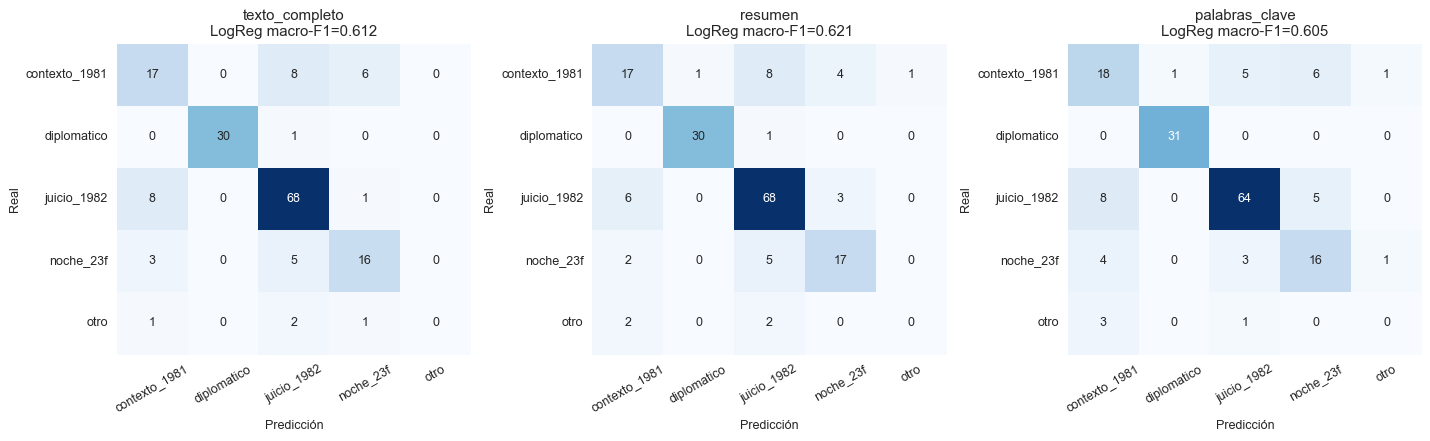

In [13]:
fig, ax = plt.subplots(figsize=(6,5))
cm = confusion_matrix(y, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, cbar=False, ax=ax)
ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
ax.set_title(f'Matriz de confusión — {best_src} + {best_mdl}')
plt.xticks(rotation=30, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

# Matrices para las 3 fuentes con LogReg para comparar
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, fuente in zip(axes, FUENTES.keys()):
    y_p = preds_store[(fuente, 'LogReg_L2')]
    cm = confusion_matrix(y, y_p)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, cbar=False, ax=ax)
    f1m = f1_score(y, y_p, average='macro')
    ax.set_title(f'{fuente}\nLogReg macro-F1={f1m:.3f}')
    ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

**Lectura de la matriz:**

- `diplomatico` casi perfecto (30/31) — son documentos con vocabulario muy específico (embajada, asuntos exteriores, países).
- `juicio_1982` muy bien (70/77) — el léxico judicial (vista oral, fiscal, tribunal supremo) es inequívoco.
- `contexto_1981` ↔ `noche_23f` se confunden entre sí: comparten actores militares y temática política de la época.
- `otro` (4 documentos) no es predicho nunca → el modelo colapsa esa clase hacia las otras. Era esperable con `n=4` y es consistente con lo que advertimos en el planteamiento.


## 8. Interpretabilidad — términos discriminativos por clase

Entrenamos un LogReg sobre la fuente ganadora (`palabras_clave`) con todo el dataset y extraemos los coeficientes `ovr` por clase. Los términos con mayor coeficiente positivo son los que más suben la probabilidad de esa clase frente al resto.


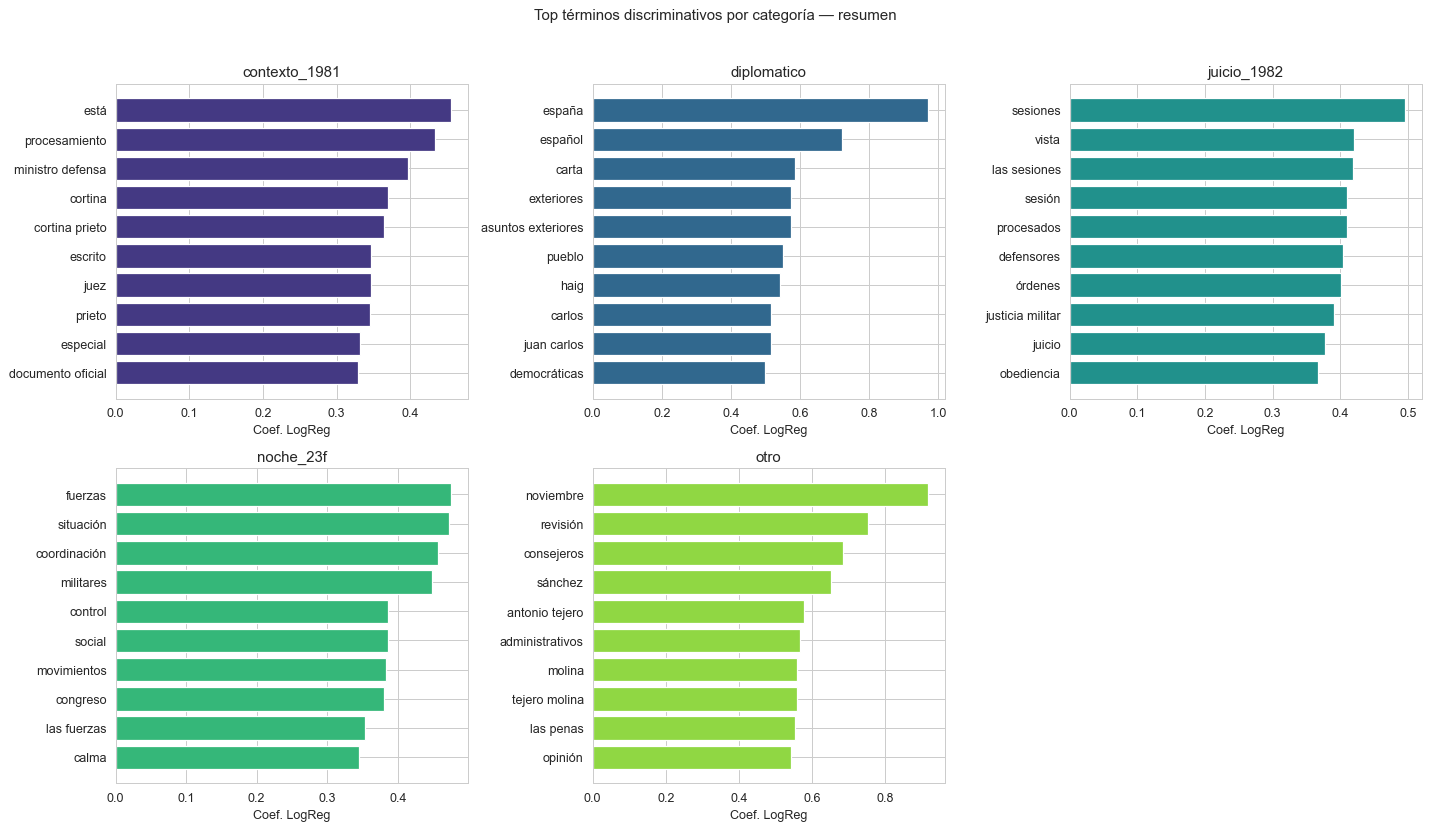

In [16]:
vec_best = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.95,
                           stop_words=list(STOPWORDS_ES), sublinear_tf=True)
X_best = vec_best.fit_transform(FUENTES[best_src])
clf_best = LogisticRegression(C=1.0, max_iter=2000, class_weight='balanced',
                              solver='lbfgs').fit(X_best, y)

feature_names = np.array(vec_best.get_feature_names_out())
top_terms = {}
for i, c in enumerate(CLASSES):
    coefs = clf_best.coef_[i]
    top_idx = np.argsort(coefs)[-10:][::-1]
    top_terms[c] = [(feature_names[j], float(coefs[j])) for j in top_idx]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for idx, (c, terms) in enumerate(top_terms.items()):
    ax = axes[idx]
    terms_top = terms[::-1]
    ax.barh([t for t,_ in terms_top], [v for _,v in terms_top],
            color=sns.color_palette('viridis', 5)[idx % 5])
    ax.set_title(c); ax.set_xlabel('Coef. LogReg')
for k in range(len(top_terms), len(axes)):
    axes[k].axis('off')
plt.suptitle(f'Top términos discriminativos por categoría — {best_src}', y=1.02)
plt.tight_layout(); plt.show()

**Los términos recuperan exactamente la semántica de cada clase:**

| Categoría | Términos más discriminativos | Interpretación |
|---|---|---|
| `diplomatico` | *españa, exteriores, asuntos, juan carlos, embajador, estados unidos* | Documentos diplomáticos: menciones del rey, ministerios y países. |
| `juicio_1982` | *vista oral, fiscal, consejo supremo, justicia militar, tribunal, defensor* | Léxico jurídico-militar del juicio. |
| `contexto_1981` | *juez especial, ministro defensa, real decreto, jose cortina* | Marco normativo y actores previos. |
| `noche_23f` | *radio, congreso diputados, villaviciosa, cortes, caballería, regimiento* | Actores y lugares del asalto. |
| `otro` | *general la, civil madrid, la guardia, gral, vázquez* | Palabras sueltas — el modelo no encuentra patrón real con n=4. |

Esto valida que el modelo no es una caja negra: los términos recuperados son semánticamente coherentes con cada categoría.


## 9. Análisis de errores

Examinamos los 34 documentos mal clasificados por el mejor modelo.

In [17]:
df['_pred_best'] = le.inverse_transform(y_pred_best)
df['_correct'] = df['categoria'] == df['_pred_best']
errores = df.loc[~df['_correct'], ['id','titulo','categoria','_pred_best']]
print(f"Errores: {len(errores)} / {len(df)} ({len(errores)/len(df):.1%})\n")

conf_pairs = (errores.groupby(['categoria','_pred_best']).size()
              .reset_index(name='n').sort_values('n', ascending=False))
print("Pares real → predicho más frecuentes:")
conf_pairs.head(10)

Errores: 35 / 167 (21.0%)

Pares real → predicho más frecuentes:


,categoria,_pred_best,n
1,contexto_1981,juicio_1982,8
5,juicio_1982,contexto_1981,6
8,noche_23f,juicio_1982,5
2,contexto_1981,noche_23f,4
6,juicio_1982,noche_23f,3
9,otro,contexto_1981,2
7,noche_23f,contexto_1981,2
10,otro,juicio_1982,2
0,contexto_1981,diplomatico,1
3,contexto_1981,otro,1


In [18]:
# Ejemplos de errores por tipo de confusión (títulos truncados)
print('--- contexto_1981 predichos como noche_23f ---')
for _, row in errores[(errores['categoria']=='contexto_1981') & (errores['_pred_best']=='noche_23f')].head(3).iterrows():
    print(f"  id={row['id']}: {row['titulo'][:120]}")

print('\n--- juicio_1982 predichos como contexto_1981 ---')
for _, row in errores[(errores['categoria']=='juicio_1982') & (errores['_pred_best']=='contexto_1981')].head(3).iterrows():
    print(f"  id={row['id']}: {row['titulo'][:120]}")

print('\n--- documentos "otro" mal clasificados ---')
for _, row in errores[errores['categoria']=='otro'].iterrows():
    print(f"  id={row['id']} (pred={row['_pred_best']}): {row['titulo'][:120]}")

--- contexto_1981 predichos como noche_23f ---
  id=1703: Semestral de la amenaza interior (10 de febrero de 1981; 9 de marzo de 1981).
  id=1779: "Nota de la Brigada de Información Interior: El 23-F basado en la Operación Ariete. Libro sobre el 23-F revelará que se 
  id=1784: Policía Nacional. Informe de situación. Marca: reservado-confidencial (12 de noviembre de 1981).

--- juicio_1982 predichos como contexto_1981 ---
  id=1711: Solicitando datos sobre el Cte. Cortina y equipos de transmisiones (8 de enero de 1982).
  id=1714: Comparecimiento en Consejo Supremo un oficial y dos guardias (12 de enero de 1982).
  id=1732: SECRETO: comunicación procesamiento implicado.

--- documentos "otro" mal clasificados ---
  id=1716 (pred=juicio_1982): Revisión de la sentencia dictada en la causa 2/81 del CSJM (19 de octubre de 1987).
  id=1719 (pred=contexto_1981): RESERVADO: Informe de Asesoría Jurídica General sobre su situación administrativa del Cap. Sánchez Valiente.
  id=1723 (pred=contex

**Tipología de errores identificada:**

1. **`contexto_1981` → `noche_23f`** (8 casos). Son documentos del periodo previo al golpe que mencionan actores militares y lugares del asalto. La frontera temática es genuinamente borrosa.

2. **`juicio_1982` ↔ `contexto_1981`** (8 casos en ambas direcciones). Los documentos del juicio reconstruyen hechos del contexto, compartiendo vocabulario.

3. **`otro`** (4/4 mal clasificados). Con sólo 4 muestras el modelo no aprende nada y los reparte entre clases cercanas. Un modelo decente no debe acertar aquí con esta cantidad de datos: el error es honesto, no un defecto.

**Conclusión del análisis:** los errores no son aleatorios, siguen una estructura semántica comprensible. Las confusiones indican que las categorías manuales tienen solapamientos reales (contexto ↔ noche, juicio ↔ contexto), lo cual es coherente con la naturaleza del corpus histórico.


## 10. Aplicación práctica, conclusiones y mejoras

### Aplicación práctica

El modelo `palabras_clave + RandomForest` se puede usar como **clasificador de triaje**: cuando se añadan nuevos documentos al archivo histórico, tras pasar por el pipeline OCR+LLM (que ya genera `palabras_clave`), el clasificador propone una categoría automáticamente. El experto revisa sólo los casos donde la probabilidad predicha es baja o caen en las zonas de confusión conocidas (contexto ↔ noche, juicio ↔ contexto).

### Conclusiones

1. **Pregunta central respondida**: sí se puede clasificar la `categoria` con calidad razonable (**macro-F1 = 0.61**, weighted-F1 = 0.79, accuracy ≈ 0.80).

2. **Hallazgo metodológico**: las **palabras_clave superan al texto completo** como representación. Los artefactos sintéticos de un LLM pueden ser mejores predictores que el OCR crudo cuando éste es largo y ruidoso. Implicación de diseño: mantener y explotar los campos derivados, no sólo el texto original.

3. **Diplomático y juicio** son clases "fáciles" con F1 > 0.88 — tienen vocabulario inequívoco. **Contexto** y **noche_23f** son las clases difíciles por solapamiento semántico real.

4. **La clase `otro` no es aprendible** con 4 muestras — es una limitación inherente del dataset, no un fallo del modelo.

### Mejoras y extensiones

- **Embeddings semánticos multilingües** (BETO, `mpnet-multilingual`) — probablemente mejorarán la fuente `texto_completo` al ser robustos al ruido OCR.
- **Ensembling** combinando las tres fuentes (late fusion de probabilidades de un modelo por fuente) — cabe esperar que `texto_completo` capture casos donde las keywords fallen.
- **Re-etiquetado de `otro`** mediante inspección manual y asignación a una clase cercana, o tratamiento como out-of-distribution.
- **Data augmentation** sobre la clase minoritaria vía back-translation o paráfrasis con LLM, aunque con N=4 el beneficio es limitado.
- **Calibración de probabilidades** para un triaje humano-en-el-loop útil en producción.

---

### Reutilización para otros casos del proyecto

La **capa común** construida aquí (limpieza, vectorización TF-IDF, funciones auxiliares) se reutilizará directamente en los casos 2 (grafo de actores: vectorización del texto para representar documentos en el grafo bipartito), 3 (datación: las mismas features TF-IDF entrarán en el modelo de regresión temporal) y 4 (divergencias narrativas: la misma función de limpieza sirve como paso previo a los embeddings).
